In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.cloud import bigquery

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
PROJECT_ID = "nyc-taxi-analytics-1"

client = bigquery.Client(project=PROJECT_ID) 

In [3]:
def run_query(query: str) -> pd.DataFrame:
    """
    Run Bigquery SQL query and return result as a panda dataframe
    """

    query_job = client.query(query)
    result = query_job.result()
    return result.to_dataframe()

In [4]:
query_kpi = """
SELECT
    total_trips,
    total_revenue,
    total_fare,
    total_tip,
    total_tolls,
    avg_revenue_per_trip,
    avg_fare_per_trip,
    avg_tip_per_trip,
    avg_trip_distance,
    avg_trip_duration_minutes,
    overall_tip_rate_percentage,
    tipped_trip_percentage,
    credit_card_trip_percentage,
    cash_trip_percentage
FROM `nyc-taxi-analytics-1.nyc_taxi_dbt_reporting.rpt_kpi_overview`
"""

df_kpi = run_query(query_kpi)
df_kpi

,total_trips,total_revenue,total_fare,total_tip,total_tolls,avg_revenue_per_trip,avg_fare_per_trip,avg_tip_per_trip,avg_trip_distance,avg_trip_duration_minutes,overall_tip_rate_percentage,tipped_trip_percentage,credit_card_trip_percentage,cash_trip_percentage
0,35359307,"1,020,936,224.13","695,079,910.69","127,869,473.49","21,138,691.36",28.87,19.66,3.62,3.57,17.47,18.40,78.70,81.83,17.17


## Monthly Trend

In [5]:
query_monthly = """
SELECT
    pickup_year_month,
    total_trips,
    previous_month_trips,
    trips_mom_growth_percentage,
    total_revenue,
    previous_month_revenue,
    revenue_mom_growth_percentage,
    total_fare,
    total_tip,
    avg_revenue_per_trip,
    avg_trip_distance,
    avg_trip_duration_minutes
FROM `nyc-taxi-analytics-1.nyc_taxi_dbt_reporting.rpt_monthly_demand_revenue`
ORDER BY pickup_year_month
"""

df_monthly = run_query(query_monthly)
df_monthly

,pickup_year_month,total_trips,previous_month_trips,trips_mom_growth_percentage,total_revenue,previous_month_revenue,revenue_mom_growth_percentage,total_fare,total_tip,avg_revenue_per_trip,avg_trip_distance,avg_trip_duration_minutes
0,2023-01,2868243,<NA>,NaN,"78,298,334.10",NaN,NaN,"52,954,592.91","9,790,104.67",27.30,3.46,15.72
1,2023-02,2717287,2868243,-5.26,"74,005,116.26","78,298,334.10",-5.48,"49,880,864.33","9,352,528.93",27.23,3.38,16.02
2,2023-03,3169021,2717287,16.62,"89,231,212.21","74,005,116.26",20.57,"60,338,247.39","11,281,879.71",28.16,3.52,16.89
3,2023-04,3057587,3169021,-3.52,"87,552,922.91","89,231,212.21",-1.88,"59,622,474.28","10,938,957.45",28.63,3.60,17.28
4,2023-05,3260640,3057587,6.64,"95,591,416.52","87,552,922.91",9.18,"65,219,277.42","11,988,480.08",29.32,3.65,18.09
5,2023-06,3066303,3260640,-5.96,"90,215,417.74","95,591,416.52",-5.62,"61,658,588.51","11,226,278.82",29.42,3.72,17.72
6,2023-07,2694638,3066303,-12.12,"78,193,062.41","90,215,417.74",-13.33,"53,612,332.76","9,494,790.91",29.02,3.75,17.11
7,2023-08,2606299,2694638,-3.28,"75,900,018.16","78,193,062.41",-2.93,"51,891,241.98","9,155,639.42",29.12,3.75,17.10
8,2023-09,2584900,2606299,-0.82,"78,221,959.33","75,900,018.16",3.06,"53,746,592.53","9,744,027.83",30.26,3.70,18.77
9,2023-10,3218306,2584900,24.50,"95,540,264.16","78,221,959.33",22.14,"65,076,038.88","12,145,903.01",29.69,3.55,18.32


In [6]:
df_monthly.info()
df_monthly.describe()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   pickup_year_month              12 non-null     str    
 1   total_trips                    12 non-null     Int64  
 2   previous_month_trips           11 non-null     Int64  
 3   trips_mom_growth_percentage    11 non-null     float64
 4   total_revenue                  12 non-null     float64
 5   previous_month_revenue         11 non-null     float64
 6   revenue_mom_growth_percentage  11 non-null     float64
 7   total_fare                     12 non-null     float64
 8   total_tip                      12 non-null     float64
 9   avg_revenue_per_trip           12 non-null     float64
 10  avg_trip_distance              12 non-null     float64
 11  avg_trip_duration_minutes      12 non-null     float64
dtypes: Int64(2), float64(9), str(1)
memory usage: 1.4 KB


,total_trips,previous_month_trips,trips_mom_growth_percentage,total_revenue,previous_month_revenue,revenue_mom_growth_percentage,total_fare,total_tip,avg_revenue_per_trip,avg_trip_distance,avg_trip_duration_minutes
count,12.00,11.00,11.00,12.00,11.00,11.00,12.00,12.00,12.00,12.00,12.00
mean,"2,946,608.92","2,937,285.91",1.05,"85,078,018.68","84,757,438.85",1.67,"57,923,325.89","10,655,789.46",28.87,3.57,17.45
std,"241,660.95","251,182.59",10.79,"7,685,265.90","7,975,779.60",11.26,"5,245,593.03","1,076,110.69",0.91,0.14,0.94
min,"2,584,900.00","2,584,900.00",-12.12,"74,005,116.26","74,005,116.26",-13.33,"49,880,864.33","9,155,639.42",27.23,3.38,15.72
25%,"2,711,624.75","2,705,962.50",-4.98,"78,214,735.10","78,207,510.87",-5.55,"53,447,897.80","9,681,718.60",28.51,3.45,17.05
50%,"3,053,374.50","3,057,587.00",-3.28,"88,078,659.87","87,552,922.91",-1.88,"59,949,870.69","11,082,618.13",29.09,3.58,17.50
75%,"3,092,446.00","3,117,971.00",3.03,"89,740,432.06","89,898,760.62",6.12,"61,016,441.58","11,336,218.47",29.34,3.71,18.17
max,"3,260,640.00","3,260,640.00",24.50,"95,591,416.52","95,591,416.52",22.14,"65,219,277.42","12,145,903.01",30.26,3.75,18.77


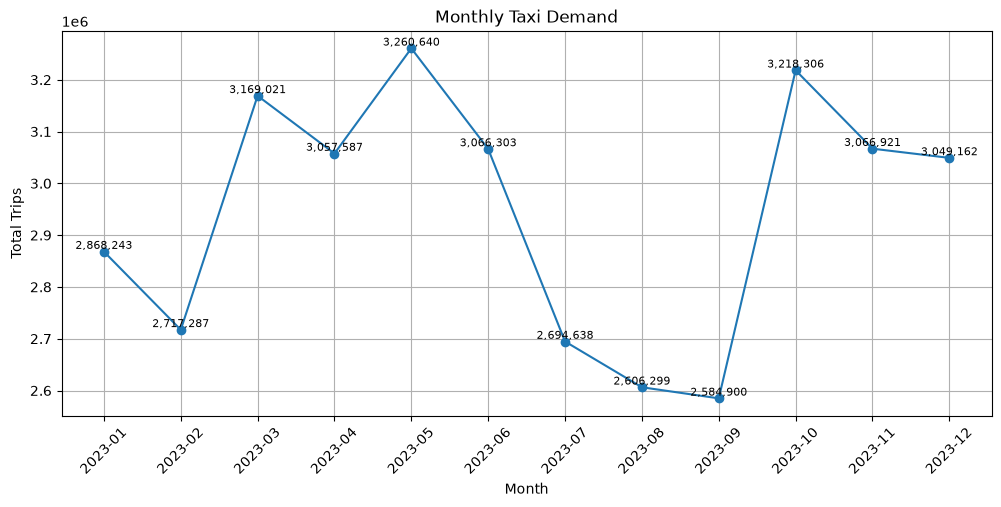

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(df_monthly["pickup_year_month"], df_monthly["total_trips"], marker="o")

for x, y in zip(df_monthly["pickup_year_month"], df_monthly["total_trips"]):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=8)

plt.title("Monthly Taxi Demand")
plt.xlabel("Month")
plt.ylabel("Total Trips")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Monthly Taxi Demand
Demand bulanan menunjukkan pola fluktuatif dengan puncaknya pada Mei dan Oktober. Penurunan paling jelas terjadi pada periode Juli hingga September, dengan titik terendah pada September. Kenaikan tajam pada Oktober menunjukkan adanya perbaikan demand.

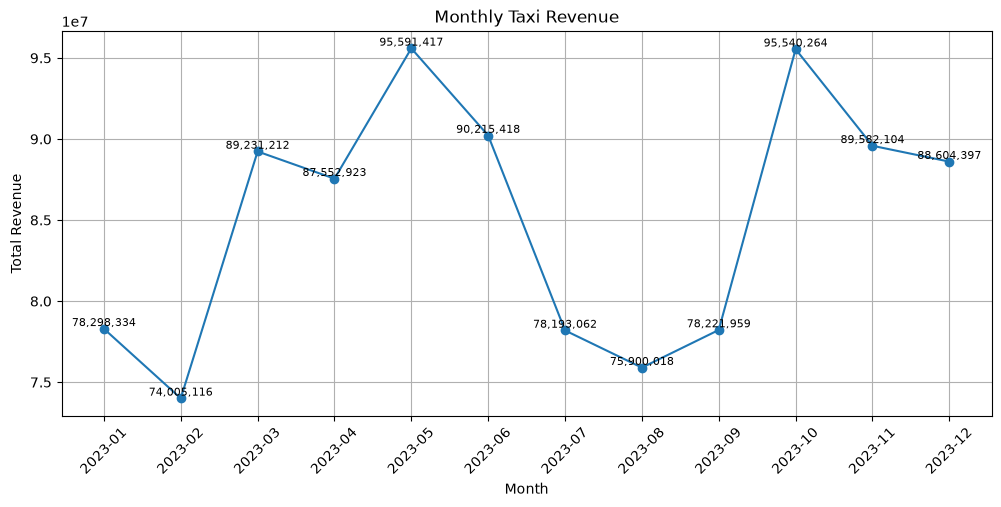

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(df_monthly["pickup_year_month"], df_monthly["total_revenue"], marker="o")

for x, y in zip(df_monthly["pickup_year_month"], df_monthly["total_revenue"]):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=8)

plt.title("Monthly Taxi Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Monthly Taxi Revenue
Revenue bulanan cenderung mengikuti pola demand, tetapi ada indikasi bahwa nilai revenue per trip juga berperan, terutama pada bulan ketika demand rendah tetapi revenue tidak turun sedalam jumlah trip.

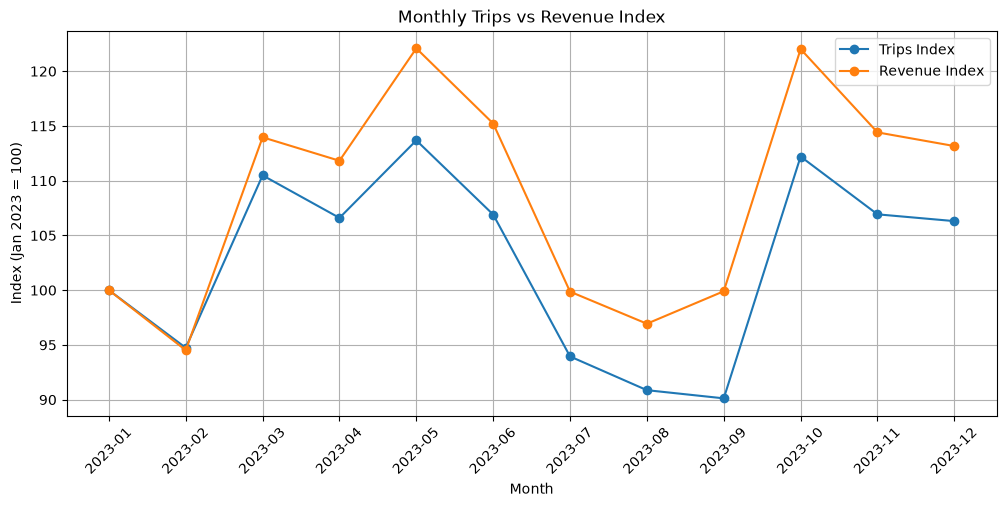

In [14]:
df_monthly["trips_index"] = (
    df_monthly["total_trips"] / df_monthly["total_trips"].iloc[0] * 100
)

df_monthly["revenue_index"] = (
    df_monthly["total_revenue"] / df_monthly["total_revenue"].iloc[0] * 100
)

plt.figure(figsize=(12, 5))
plt.plot(df_monthly["pickup_year_month"], df_monthly["trips_index"], marker="o", label="Trips Index")
plt.plot(df_monthly["pickup_year_month"], df_monthly["revenue_index"], marker="o", label="Revenue Index")
plt.title("Monthly Trips vs Revenue Index")
plt.xlabel("Month")
plt.ylabel("Index (Jan 2023 = 100)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

revenue bergerak searah dengan demand, tetapi revenue tumbuh lebih kuat daripada jumlah trip di banyak bulan. Ini berarti performa revenue tidak hanya ditentukan oleh volume, tetapi juga oleh nilai rata-rata per perjalanan.

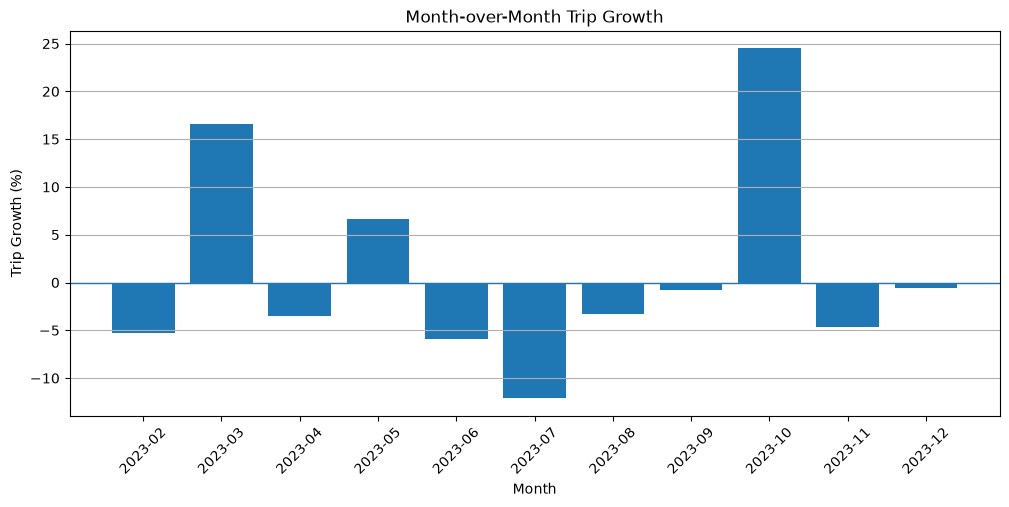

In [18]:
plt.figure(figsize=(12, 5))
plt.bar(
    df_monthly["pickup_year_month"],
    df_monthly["trips_mom_growth_percentage"]
)
plt.title("Month-over-Month Trip Growth")
plt.xlabel("Month")
plt.ylabel("Trip Growth (%)")
plt.xticks(rotation=45)
plt.axhline(0, linewidth=1)
plt.grid(axis="y")
plt.show()

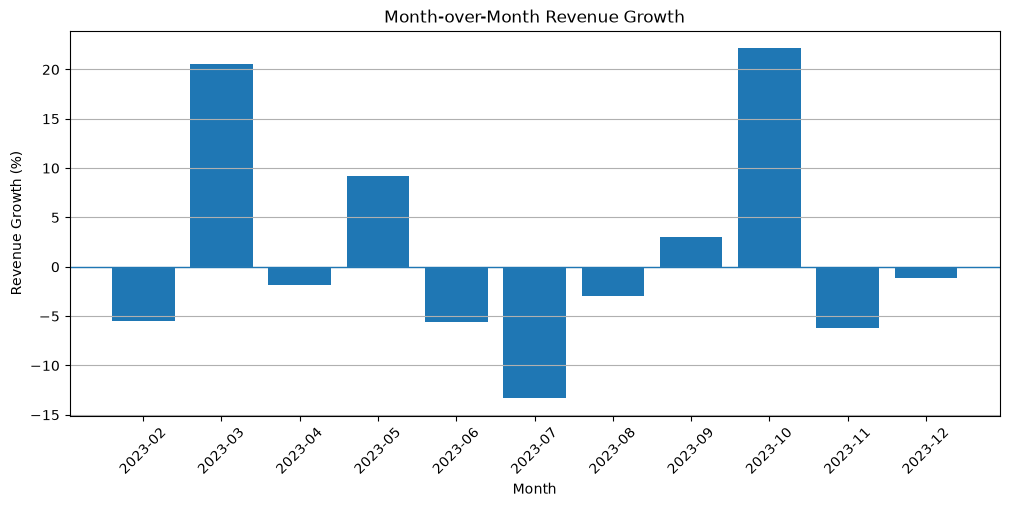

In [22]:
plt.figure(figsize=(12, 5))
plt.bar(
    df_monthly["pickup_year_month"],
    df_monthly["revenue_mom_growth_percentage"]
)
plt.title("Month-over-Month Revenue Growth")
plt.xlabel("Month")
plt.ylabel("Revenue Growth (%)")
plt.xticks(rotation=45)
plt.axhline(0, linewidth=1)
plt.grid(axis="y")
plt.show()

### Month-over-month Trip and Revenue Growth
Analisis month-over-month menunjukkan bahwa pertumbuhan jumlah trip dan revenue secara umum bergerak searah sepanjang 2023. Pertumbuhan paling kuat terjadi pada Oktober, ketika jumlah trip meningkat sekitar 24% dan revenue meningkat sekitar 22% dibanding September. Hal ini menunjukkan adanya recovery yang kuat pada demand dan revenue setelah periode pelemahan di pertengahan tahun.

Penurunan terdalam terjadi pada Juli, ketika baik trip maupun revenue turun signifikan dibanding Juni. Ini menunjukkan bahwa pelemahan pada pertengahan tahun tidak hanya terjadi dari sisi volume perjalanan, tetapi juga berdampak langsung terhadap performa revenue.

Secara umum, revenue growth mengikuti arah trip growth, yang mengindikasikan bahwa total revenue sangat dipengaruhi oleh volume trip. Namun, September menjadi pengecualian menarik karena trip growth sedikit negatif, sementara revenue growth positif. Kondisi ini menunjukkan kemungkinan adanya peningkatan revenue per trip, yang dapat disebabkan oleh trip yang lebih panjang, fare lebih tinggi, tip lebih besar, atau perubahan komposisi perjalanan.

## Peak hour Analysis

In [10]:
query_peak_hour = """
SELECT
    pickup_hour,
    pickup_time_period,
    total_trips,
    total_revenue,
    avg_revenue_per_trip,
    avg_trip_distance,
    avg_trip_duration_minutes,
    demand_rank,
    revenue_rank
FROM `nyc-taxi-analytics-1.nyc_taxi_dbt_reporting.peak_hour_analysis`
ORDER BY pickup_hour
"""

df_peak_hour = run_query(query_peak_hour)
df_peak_hour.head()

,pickup_hour,pickup_time_period,total_trips,total_revenue,avg_revenue_per_trip,avg_trip_distance,avg_trip_duration_minutes,demand_rank,revenue_rank
0,0,Late night,993738,"29,104,583.22",29.29,4.00,15.92,17,17
1,1,Late night,664396,"17,739,452.95",26.70,3.56,15.17,19,19
2,2,Late night,435923,"10,986,456.87",25.20,3.37,14.02,21,21
3,3,Late night,282756,"7,461,934.98",26.39,3.55,14.34,22,22
4,4,Late night,176685,"5,936,501.38",33.60,5.01,15.62,24,24


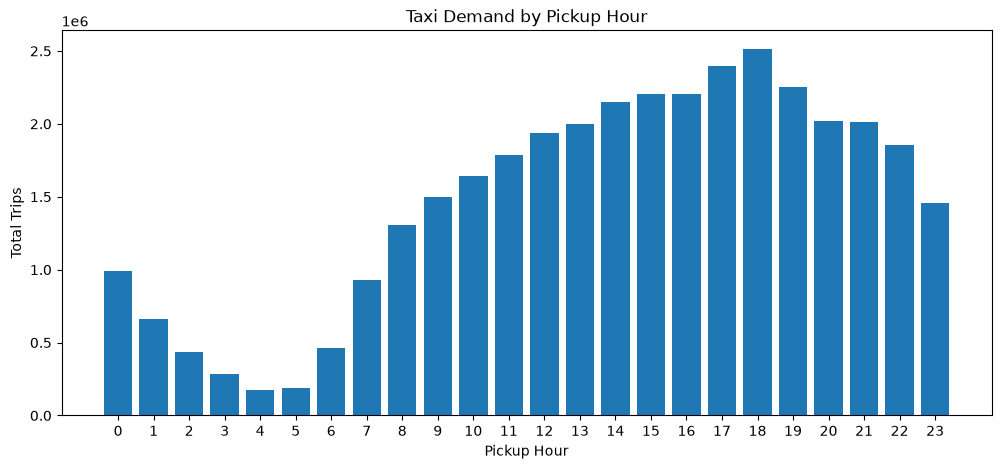

In [11]:
plt.figure(figsize=(12, 5))
plt.bar(df_peak_hour["pickup_hour"], df_peak_hour["total_trips"])
plt.title("Taxi Demand by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Total Trips")
plt.xticks(range(0, 24))
plt.show()

### Demand by Pickup Hour
Analisis demand per jam menunjukkan pola mobilitas harian yang jelas. Demand taxi berada pada titik terendah pada periode dini hari, terutama sekitar jam 04:00–05:00, kemudian mulai meningkat sejak jam 06:00 seiring dimulainya aktivitas harian. Demand terus meningkat sepanjang hari dan mencapai puncaknya pada periode sore hingga awal malam, terutama sekitar jam 18:00. Setelah jam 19:00, demand mulai menurun secara bertahap, tetapi tetap relatif tinggi hingga malam.

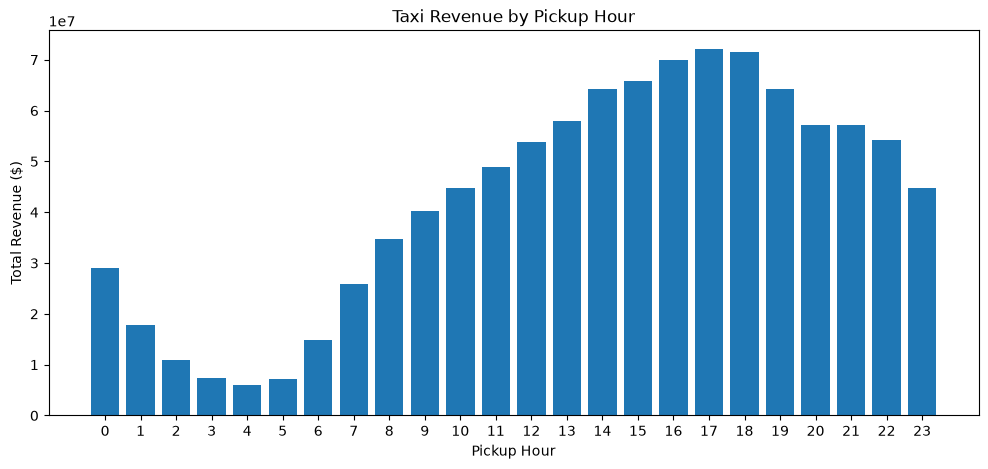

In [24]:
plt.figure(figsize=(12, 5))
plt.bar(df_peak_hour["pickup_hour"], df_peak_hour["total_revenue"])
plt.title("Taxi Revenue by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Total Revenue ($)")
plt.xticks(range(0, 24))
plt.show()


### Revenue by Pickup Hour
Pola revenue terlihat sangat mirip dengan pola demand, yang menunjukkan bahwa revenue per jam sangat dipengaruhi oleh volume trip. Revenue tertinggi terjadi sekitar jam 17:00–18:00, hampir sama dengan periode peak demand. Namun, peak revenue terlihat sedikit lebih awal dibanding peak demand, sehingga ada indikasi bahwa rata-rata revenue per trip pada jam 17:00 mungkin lebih tinggi dibanding jam 18:00. Analisis lanjutan terhadap average revenue per trip, trip distance, dan trip duration per jam diperlukan untuk memastikan hal tersebut.

Secara keseluruhan, periode sore hingga awal malam merupakan window operasional terkuat untuk Yellow Taxi, baik dari sisi demand maupun revenue. Sebaliknya, periode dini hari merupakan window dengan performa demand dan revenue paling rendah.

## Payment Behaviour

In [28]:
query_payment = f"""
SELECT
    payment_type_id,
    payment_type_name,
    payment_category,
    total_trips,
    trip_share_percentage,
    total_revenue,
    revenue_share_percentage,
    total_fare,
    total_tip,
    avg_revenue_per_trip,
    avg_fare_per_trip,
    avg_tip_per_trip,
    tip_rate_percentage,
    tipped_trip_percentage
FROM `{PROJECT_ID}.nyc_taxi_dbt_reporting.rpt_payment_behaviour`
ORDER BY total_trips DESC
"""

df_payment = run_query(query_payment)
df_payment

,payment_type_id,payment_type_name,payment_category,total_trips,trip_share_percentage,total_revenue,revenue_share_percentage,total_fare,total_tip,avg_revenue_per_trip,avg_fare_per_trip,avg_tip_per_trip,tip_rate_percentage,tipped_trip_percentage
0,1,Cash,Cash payment,28934564,81.83,"858,074,425.90",84.05,"566,417,945.22","127,860,454.42",29.66,19.58,4.42,22.57,96.17
1,2,No charge,Non-revenue,6071589,17.17,"153,934,564.22",15.08,"121,650,655.32","1,912.30",25.35,20.04,0.00,0.00,0.01
2,4,Unknown,Unknown,235101,0.66,"6,113,382.81",0.60,"4,820,451.71","5,774.07",26.00,20.50,0.02,0.12,0.15
3,3,Dispute,Exception,118053,0.33,"2,813,851.20",0.28,"2,190,858.44","1,332.70",23.84,18.56,0.01,0.06,0.11


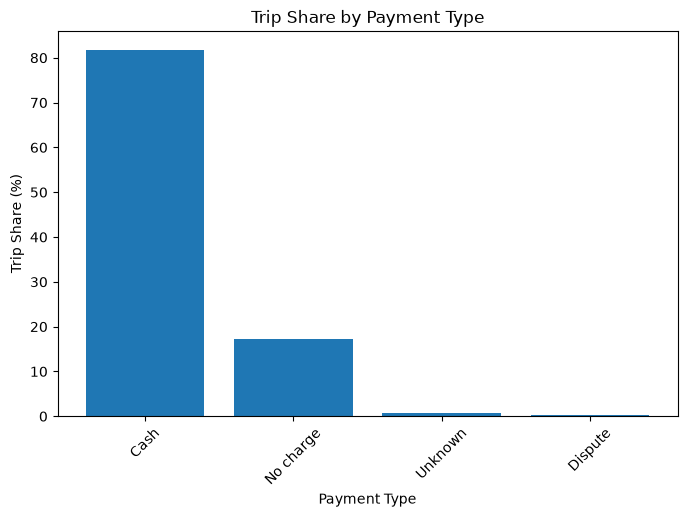

In [29]:
plt.figure(figsize=(8, 5))
plt.bar(df_payment["payment_type_name"], df_payment["trip_share_percentage"])
plt.title("Trip Share by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Trip Share (%)")
plt.xticks(rotation=45)
plt.show()

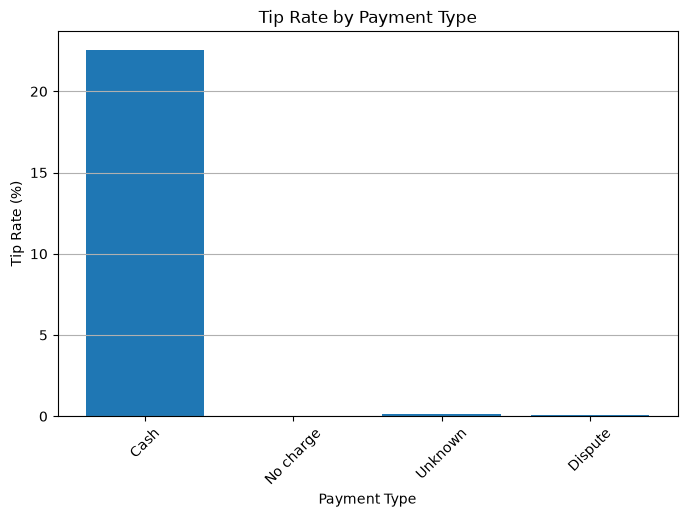

In [30]:
plt.figure(figsize=(8, 5))
plt.bar(df_payment["payment_type_name"], df_payment["tip_rate_percentage"])
plt.title("Tip Rate by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Tip Rate (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()